# Задание 3.

In [27]:
import pandas as pd
import matplotlib
from datetime import date
MIN_ZARPLATA = 20000

Составить таблицу, содержащую поля №, ФИО, дату рождения, месяц выплаты пособия

Заполнить таблицу

In [28]:
data = {
    "ФИО": ["Иванов И.И.", "Петров И.И.", "Сидоров И.И.", "Кузнецов И.И.", "Ширшанов Н.А.", "Давидчук В.Р.", "Забродина Р.А.", "Забродина Н.А.", "Иванов И.И.", "Петров И.И."],
    "Дата рождения": [
        "2023-05-10",
        "2019-03-15",
        "2014-07-20",
        "2004-11-01",
        "2023-01-05",
        "2018-09-12",
        "2013-02-28",
        "2005-06-17",
        "2024-02-01",
        "2017-04-03",
    ][:10],
    "Месяц выплаты": ["Январь"] * 4 + ["Февраль"] * 4 + ["Март"] * 2,
}
df = pd.DataFrame(data)
df.insert(0, "№ п/п", range(1, len(df) + 1))


Добавить столбец возраст

In [29]:
df["Дата рождения"] = pd.to_datetime(df["Дата рождения"])
df["Возраст"] = (pd.Timestamp.today() - df["Дата рождения"]).dt.days // 365

Добавить столбец сумма пособия

In [30]:
def posobie(age):
    if age < 3:   return MIN_ZARPLATA * 1.0
    if age < 8:   return MIN_ZARPLATA * 0.8
    if age <= 17: return MIN_ZARPLATA * 0.6
    return 0

df["Сумма пособия"] = df["Возраст"].apply(posobie)

print(df)

   № п/п             ФИО Дата рождения Месяц выплаты  Возраст  Сумма пособия
0      1     Иванов И.И.    2023-05-10        Январь        3        16000.0
1      2     Петров И.И.    2019-03-15        Январь        7        16000.0
2      3    Сидоров И.И.    2014-07-20        Январь       12        12000.0
3      4   Кузнецов И.И.    2004-11-01        Январь       21            0.0
4      5   Ширшанов Н.А.    2023-01-05       Февраль        3        16000.0
5      6   Давидчук В.Р.    2018-09-12       Февраль        8        12000.0
6      7  Забродина Р.А.    2013-02-28       Февраль       13        12000.0
7      8  Забродина Н.А.    2005-06-17       Февраль       21            0.0
8      9     Иванов И.И.    2024-02-01          Март        2        20000.0
9     10     Петров И.И.    2017-04-03          Март        9        12000.0


Вычислить общую сумму пособий

In [31]:
print("Общая сумма пособий:", df["Сумма пособия"].sum())

Общая сумма пособий: 116000.0


Вычислить средний возраст детей

In [32]:
print("Средний возраст:", round(df["Возраст"].mean(), 2))

Средний возраст: 9.9


Определить количество детей старше 8

In [33]:
print("Детей старше 8 лет:", (df["Возраст"] > 8).sum())

Детей старше 8 лет: 5


Вычислить общую сумму пособия по фамилиям, представить в виде таблицы

In [34]:
print(df.groupby("ФИО")["Сумма пособия"].sum())

ФИО
Давидчук В.Р.     12000.0
Забродина Н.А.        0.0
Забродина Р.А.    12000.0
Иванов И.И.       36000.0
Кузнецов И.И.         0.0
Петров И.И.       28000.0
Сидоров И.И.      12000.0
Ширшанов Н.А.     16000.0
Name: Сумма пособия, dtype: float64


Вычислить сумму пособий по месяцам, оформить в виде таблицы

In [35]:
print(df.groupby("Месяц выплаты")["Сумма пособия"].sum())

Месяц выплаты
Март       32000.0
Февраль    40000.0
Январь     44000.0
Name: Сумма пособия, dtype: float64


Построить диаграмму выплат по месяцам

<Axes: title={'center': 'Выплаты по месяцам'}, xlabel='Месяц выплаты'>

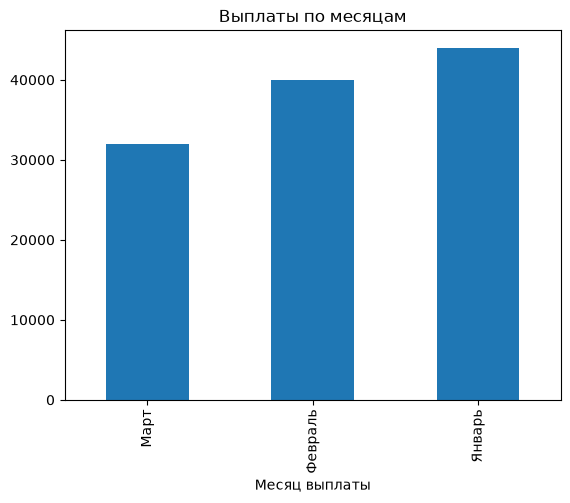

In [36]:
df.groupby("Месяц выплаты")["Сумма пособия"].sum().plot(kind="bar", title="Выплаты по месяцам")